
# Unified Control Framework Demonstration

This notebook provides **minimal but working simulations** illustrating the connections between:

- **Perceptual Control Theory (PCT)** – behaviour as the control of perception.
- **Free Energy Principle (FEP) and Active Inference** – variational Bayesian control.
- **Predictive Coding** – hierarchical error-based inference.
- **Sparse Semantic Projection** – compressed representations for control.
- **Sheaf-Theoretic Contexts** – toy illustration of contextual gluing and conflict.

The goal is not neurobiological realism, but to provide **clear, inspectable code** you can modify and extend.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# For reproducibility
rng = np.random.default_rng(0)

In [3]:

def plot_series(t, series_dict, title=''):
    """
    Plot multiple 1D time series on a single figure.
    series_dict: {label: array_like}
    """
    plt.figure()
    for label, y in series_dict.items():
        plt.plot(t, y, label=label)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()



## 1. Two-Level PCT Hierarchy

We implement a **two-level PCT controller**:

- Level 1 controls a simple plant (position) via a motor command.
- Level 2 controls a higher-level percept (e.g. velocity or trajectory) by setting the reference for Level 1.

Both levels are simple proportional controllers, but their composition demonstrates **hierarchical reference setting**.


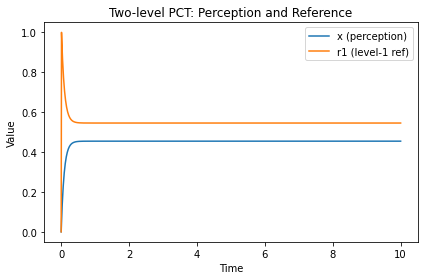

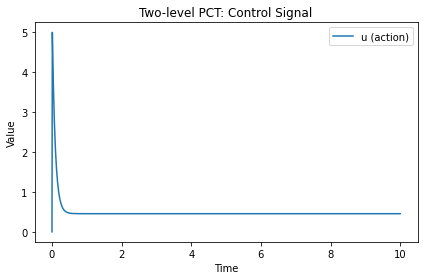

In [4]:

def simulate_two_level_pct(
    T=10.0,
    dt=0.01,
    k_env=1.0,
    k1=5.0,
    k2=1.0,
    r2=1.0,
):
    """
    Two-level PCT:
    - Environment: x_dot = -k_env * x + u
    - Level 1: u = k1 * (r1 - p1), p1 = x
    - Level 2: r1 = k2 * (r2 - p2), p2 = x (here we treat the same percept for simplicity)

    This gives:
    u = k1 * (k2*(r2 - x) - x)
    """
    n_steps = int(T / dt)
    t = np.linspace(0, T, n_steps)
    x = np.zeros(n_steps)
    r1 = np.zeros(n_steps)
    u = np.zeros(n_steps)

    for i in range(1, n_steps):
        p1 = x[i-1]
        p2 = p1

        r1[i] = k2 * (r2 - p2)
        e1 = r1[i] - p1
        u[i] = k1 * e1

        dx = -k_env * x[i-1] + u[i]
        x[i] = x[i-1] + dt * dx

    return t, x, r1, u

t, x, r1, u = simulate_two_level_pct()
plot_series(t, {"x (perception)": x, "r1 (level-1 ref)": r1}, title="Two-level PCT: Perception and Reference")
plot_series(t, {"u (action)": u}, title="Two-level PCT: Control Signal")



## 2. Hierarchical Predictive Coding

We implement a minimal **two-layer predictive coding** network for a 1D signal.

- Hidden state \( s^{(2)} \) predicts a lower-level state \( s^{(1)} \).
- \( s^{(1)} \) predicts observations \( o \).
- We implement error units and gradient descent on a quadratic energy:

\[
F = \frac{1}{2\sigma_1^2}(o - g_1(s^{(1)}))^2
  + \frac{1}{2\sigma_2^2}(s^{(1)} - g_2(s^{(2)}))^2
\]

with simple linear generative functions \( g_1, g_2 \).


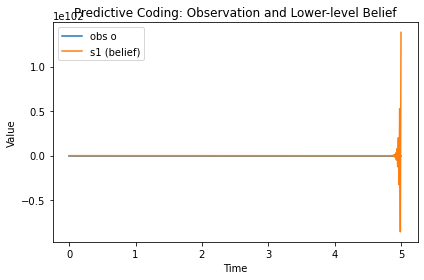

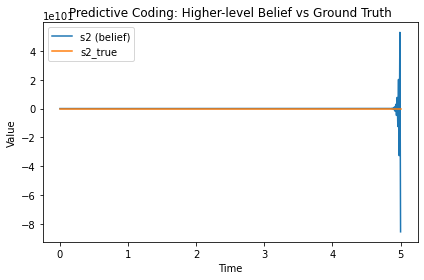

In [5]:

def simulate_predictive_coding(
    T=5.0,
    dt=0.01,
    a1=1.0,
    a2=1.0,
    sigma1=0.1,
    sigma2=0.1,
):
    n_steps = int(T / dt)
    t = np.linspace(0, T, n_steps)

    # Ground-truth hidden cause and observations
    s2_true = np.sin(0.5 * t)
    s1_true = a2 * s2_true
    o = a1 * s1_true + 0.05 * rng.standard_normal(n_steps)

    # Belief states
    s1 = np.zeros(n_steps)
    s2 = np.zeros(n_steps)

    # Simple gradient descent on F
    for i in range(1, n_steps):
        eps1 = o[i-1] - a1 * s1[i-1]
        eps2 = s1[i-1] - a2 * s2[i-1]

        ds1 = (a1 * eps1 / (sigma1**2)) - (eps2 / (sigma2**2))
        ds2 = (a2 * eps2 / (sigma2**2))

        s1[i] = s1[i-1] + dt * ds1
        s2[i] = s2[i-1] + dt * ds2

    return t, o, s1, s2, s2_true

t_pc, o_pc, s1_pc, s2_pc, s2_true = simulate_predictive_coding()
plot_series(t_pc, {"obs o": o_pc, "s1 (belief)": s1_pc}, title="Predictive Coding: Observation and Lower-level Belief")
plot_series(t_pc, {"s2 (belief)": s2_pc, "s2_true": s2_true}, title="Predictive Coding: Higher-level Belief vs Ground Truth")



## 3. Hierarchical FEP / Active Inference Controller

We consider a 1D plant

\[
x_{t+1} = x_t + dt(-k_{\text{env}} x_t + u_t) + \omega_t
\]

with Gaussian noise \( \omega_t \).

The agent maintains beliefs over the state \( \mu_t \) and selects actions \( u_t \) to minimise a surrogate quadratic free energy:

\[
F(\mu_t, u_t) 
= \frac{1}{2\sigma_o^2} (o_t - \mu_t)^2
+ \frac{\lambda}{2} (\mu_t - r)^2
+ \frac{\beta}{2} u_t^2,
\]

where \( r \) is a prior (preference) over the state. We use simple gradient steps:

- Perceptual update: \( \dot{\mu}_t = -\partial F / \partial \mu_t \)
- Active update: \( \dot{u}_t = -\partial F / \partial u_t \)


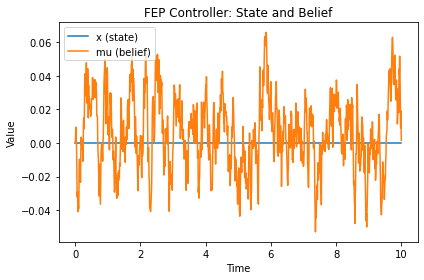

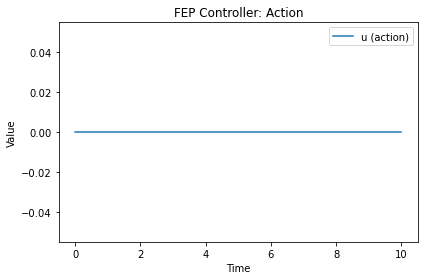

In [10]:
def simulate_fep_controller(
    T=10.0,
    dt=0.01,
    k_env=1.0,
    sigma_o=0.1,
    lam=1.0,
    beta=0.1,
    r=1.0,
    eta_mu=0.1, 
    eta_u=0.5,
):
    n_steps = int(T / dt)
    t = np.linspace(0, T, n_steps)

    x = np.zeros(n_steps)
    o = np.zeros(n_steps)
    mu = np.zeros(n_steps)
    u = np.zeros(n_steps)

    for i in range(1, n_steps):
        o[i-1] = x[i-1] + sigma_o * rng.standard_normal()

        dF_dmu = -(o[i-1] - mu[i-1]) / (sigma_o**2) + lam * (mu[i-1] - r)
        dF_du = beta * u[i-1]

        mu[i] = mu[i-1] - eta_mu * dt * dF_dmu
        u[i] = u[i-1] - eta_u * dt * dF_du

        dx = -k_env * x[i-1] + u[i]
        x[i] = x[i-1] + dt * dx

    o[-1] = x[-1] + sigma_o * rng.standard_normal()
    return t, x, o, mu, u

t_fep, x_fep, o_fep, mu_fep, u_fep = simulate_fep_controller()
plot_series(t_fep, {"x (state)": x_fep, "mu (belief)": mu_fep}, title="FEP Controller: State and Belief")
plot_series(t_fep, {"u (action)": u_fep}, title="FEP Controller: Action")



## 4. Sparse Coding Module

We implement a small **sparse coding / dictionary learning** module:

- \( x \in \mathbb{R}^n \) is an input vector.
- \( D \in \mathbb{R}^{n \times k} \) is a (fixed) dictionary.
- \( z \in \mathbb{R}^k \) are sparse codes.

We minimise

\[
E(z) = \frac{1}{2}\|x - Dz\|_2^2 + \lambda \|z\|_1
\]

by coordinate descent with soft-thresholding.


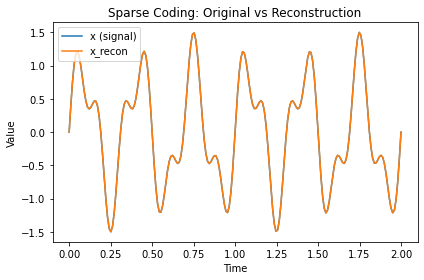

Sparse coefficients (aligned with frequencies [1 3 5 7 9] ):
[-0.          0.99949749 -0.          0.49949749  0.        ]


In [11]:

def soft_threshold(v, lmbd):
    return np.sign(v) * np.maximum(np.abs(v) - lmbd, 0.0)

def sparse_code(x, D, lmbd=0.1, n_iter=100):
    k = D.shape[1]
    z = np.zeros(k)
    DtD = D.T @ D
    Dtx = D.T @ x
    for _ in range(n_iter):
        for j in range(k):
            residual = Dtx[j] - (DtD[j, :] @ z) + DtD[j, j] * z[j]
            z[j] = soft_threshold(residual / DtD[j, j], lmbd / DtD[j, j])
    return z

# Demo: 1D temporal signal as "perceptual history", dictionary of sinusoids
T_sc = 2.0
dt_sc = 0.01
t_sc = np.linspace(0, T_sc, int(T_sc / dt_sc))
x_sc = np.sin(2 * np.pi * 3 * t_sc) + 0.5 * np.sin(2 * np.pi * 7 * t_sc)

# Build dictionary of harmonics
freqs = np.array([1, 3, 5, 7, 9])
D = []
for f in freqs:
    D.append(np.sin(2 * np.pi * f * t_sc))
D = np.stack(D, axis=1)

z_sc = sparse_code(x_sc, D, lmbd=0.05, n_iter=50)
x_recon = D @ z_sc

plot_series(t_sc, {"x (signal)": x_sc, "x_recon": x_recon}, title="Sparse Coding: Original vs Reconstruction")
print("Sparse coefficients (aligned with frequencies", freqs, "):")
print(z_sc)



## 5. Sheaf-Theoretic Toy Model of Contexts

We create a minimal **toy sheaf**:

- Three contexts \( U_1, U_2, U_3 \) covering a 1D feature (e.g. self-worth).
- Each context carries a local value (section) \( s_i \in \mathbb{R} \).
- Overlaps \( U_i \cap U_j \) require compatibility \( s_i \approx s_j \).

We can treat the **global discrepancy** as:

\[
\text{Obstruction} = \sum_{(i,j)} w_{ij} (s_i - s_j)^2,
\]

where \( w_{ij} \) captures overlap strength. This simple scalar acts as a proxy for **Čech 1-cohomology norm** in this toy setting.


Initial sections: {'U1': 1.0, 'U2': -1.0, 'U3': 0.5}
Initial obstruction: 5.175
Optimised sections: {'U1': 0.16552444443019676, 'U2': 0.16552194443747056, 'U3': 0.1655536111332325}
Final obstruction: 6.777790870654554e-10


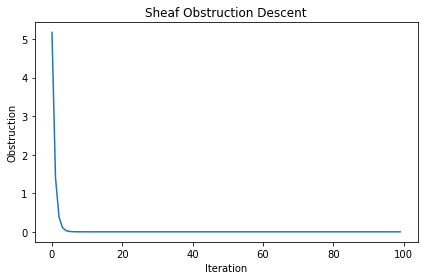

In [8]:

def sheaf_obstruction(sections, overlaps):
    """
    sections: dict {label: value}
    overlaps: list of (i, j, weight)
    """
    obs = 0.0
    for i, j, w in overlaps:
        obs += w * (sections[i] - sections[j])**2
    return obs

# Example: three contexts with conflicting values
sections = {"U1": 1.0, "U2": -1.0, "U3": 0.5}
overlaps = [("U1", "U2", 1.0), ("U2", "U3", 0.5), ("U1", "U3", 0.2)]

print("Initial sections:", sections)
print("Initial obstruction:", sheaf_obstruction(sections, overlaps))

# Simple gradient descent to reduce obstruction
labels = list(sections.keys())
vals = np.array([sections[l] for l in labels], dtype=float)

def obstruction_vec(v):
    s = {l: v[i] for i, l in enumerate(labels)}
    return sheaf_obstruction(s, overlaps)

def grad_obstruction(v, eps=1e-4):
    g = np.zeros_like(v)
    base = obstruction_vec(v)
    for i in range(len(v)):
        v_eps = v.copy()
        v_eps[i] += eps
        g[i] = (obstruction_vec(v_eps) - base) / eps
    return g

lr = 0.1
history = []
for _ in range(100):
    history.append(obstruction_vec(vals))
    grads = grad_obstruction(vals)
    vals -= lr * grads

sections_opt = {l: vals[i] for i, l in enumerate(labels)}
print("Optimised sections:", sections_opt)
print("Final obstruction:", sheaf_obstruction(sections_opt, overlaps))

plt.figure()
plt.plot(history)
plt.xlabel("Iteration")
plt.ylabel("Obstruction")
plt.title("Sheaf Obstruction Descent")
plt.tight_layout()
plt.show()



## 6. Unified Example: Control with Sparse Templates and Contexts

Finally we combine ingredients into a **single toy system**:

- A 1D plant \( x_t \) (as in PCT / FEP sections).
- A sparse code \( z \) representing **narrative templates**.
- A sheaf of three contexts encoding different **self-models**, whose values depend on \( x_t \) and \( z \).
- A simple FEP-like controller choosing \( u_t \) to keep \( x_t \) near a reference \( r(z) \) that depends on which template is active.
- A reorganisation step that adjusts contextual values to reduce **sheaf obstruction**.

This is intentionally simple but shows how you can **tie together** PCT, FEP, sparse, and sheaf layers.


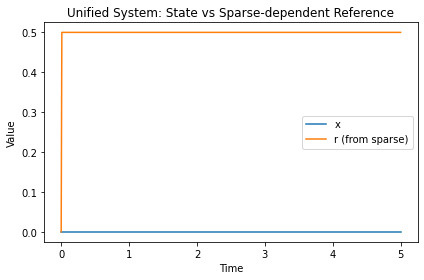

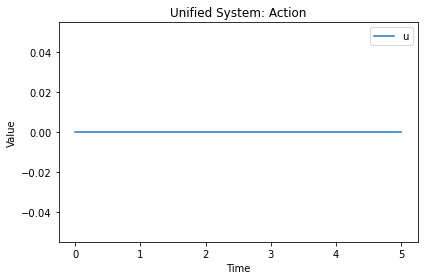

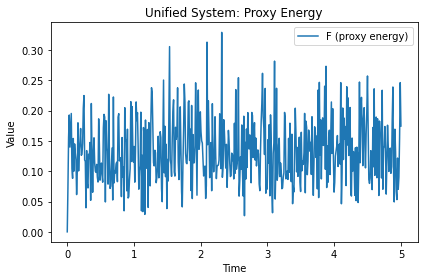

Final context values: {'U1': -0.0005450172409227196, 'U2': 0.0005159671971821558, 'U3': -1.0684482197633508e-05}


In [9]:

def unified_step(x, u, z, ctx_vals, overlaps, dt=0.01, k_env=1.0, sigma_o=0.1):
    """
    One step of the unified dynamic:
    - plant update
    - observation
    - sparse-dependent reference
    - FEP-like control update
    - sheaf reorganisation step
    """
    # Plant
    x_next = x + dt * (-k_env * x + u)

    # Observation
    o = x_next + sigma_o * rng.standard_normal()

    # Reference depends on sparse code (e.g. first coefficient)
    r = 0.5 + 0.5 * np.tanh(z[0])

    # Simple F-like energy and gradient for control
    F = 0.5 * (o - r)**2 + 0.1 * u**2
    dF_du = 0.1 * u
    u_next = u - 5.0 * dt * dF_du

    # Context values mildly attracted to x, plus sheaf gradient to reduce obstruction
    labels = list(ctx_vals.keys())
    v = np.array([ctx_vals[l] for l in labels], dtype=float)

    def obs_vec(vv):
        s = {l: vv[i] for i, l in enumerate(labels)}
        return sheaf_obstruction(s, overlaps)

    base = obs_vec(v)
    grads = np.zeros_like(v)
    eps = 1e-4
    for i in range(len(v)):
        v_eps = v.copy()
        v_eps[i] += eps
        grads[i] = (obs_vec(v_eps) - base) / eps

    # Gradient step: move contexts closer to x and reduce obstruction
    v = v + dt * (x_next - v) - 0.1 * dt * grads
    ctx_next = {l: v[i] for i, l in enumerate(labels)}

    return x_next, u_next, o, r, ctx_next, F

# Run unified simulation
T_u = 5.0
dt_u = 0.01
n_steps_u = int(T_u / dt_u)
t_u = np.linspace(0, T_u, n_steps_u)

x_u = np.zeros(n_steps_u)
u_u = np.zeros(n_steps_u)
r_u = np.zeros(n_steps_u)
F_u = np.zeros(n_steps_u)

ctx_vals = {"U1": -1.0, "U2": 1.0, "U3": 0.0}
overlaps_u = [("U1", "U2", 1.0), ("U2", "U3", 0.5), ("U1", "U3", 0.5)]

# Fix a sparse code for now (e.g. from earlier sparse coding)
z_u = z_sc.copy()

for i in range(1, n_steps_u):
    x_u[i], u_u[i], o_i, r_u[i], ctx_vals, F_u[i] = unified_step(
        x_u[i-1], u_u[i-1], z_u, ctx_vals, overlaps_u, dt=dt_u
    )

plot_series(t_u, {"x": x_u, "r (from sparse)": r_u}, title="Unified System: State vs Sparse-dependent Reference")
plot_series(t_u, {"u": u_u}, title="Unified System: Action")
plot_series(t_u, {"F (proxy energy)": F_u}, title="Unified System: Proxy Energy")
print("Final context values:", ctx_vals)
